## Importing the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Reading the Training Dataset using Pandas

In [2]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")

Familiarizing with the data by reviewing the first 10 rows of the dataset and viewing the information about the data

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## INFORMATION ABOUT THE COLUMNS:

PassengerId - PassengerId column contains the Ids of the passengers.

Survived - Survived column shows whether a particular passenger has survived the tragic accident, here  1 represents that the particular passenger has survived and 0 represents that passenger has not survived. 

Pclass - This column holds the information regarding the Ticket class, where	1 = 1st class, 2 = 2nd class and 3 = 3rd class.

Sex	- Contains the gender information of the passengers, where 1 represents 'Male' and 0 represents 'Female'.

Age	- This column contains Age in years	

Sibsp -  This column has the information of siblings / spouses a passenger has aboard the Titanic.	

Parch - It shows if a passenger has any of parents / children aboard the Titanic.	

Ticket	- Contains the Ticket number of the passenger

Fare - Contains the Passenger fare.	

Cabin -  Contains the Cabin number.	

Embarked - This column contains the information about the Port of Embarkation of the passengers. 
Here	C = Cherbourg, Q = Queenstown, S = Southampton

## Data Preprocessing

Checking for Null Values in the Training Dataset


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Here we can observe that 'Age', 'Cabin' and 'Embarked' Columns have Null values.

We need to handle the missing values in the dataset as missing values in data will lead to drawing inaccurate inference about the data.

In [6]:
#Imputing null values: Missing values can be imputed using the statistics i.e., using mean value for float or int datatype 
#and mode for object datatype.


for i in df.columns:
  if df[i].dtypes == 'object':
    df[i] = df[i].fillna(df[i].mode()[0])
  else:
    df[i] = df[i].fillna(df[i].mean())

In [7]:
#Checking for null values after imputation
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Checking for Duplicate values in Traning Dataset

In [8]:
df.duplicated().sum()

0

We can observe that there are no duplicate values in the Traning Dataset

## Data Visualization

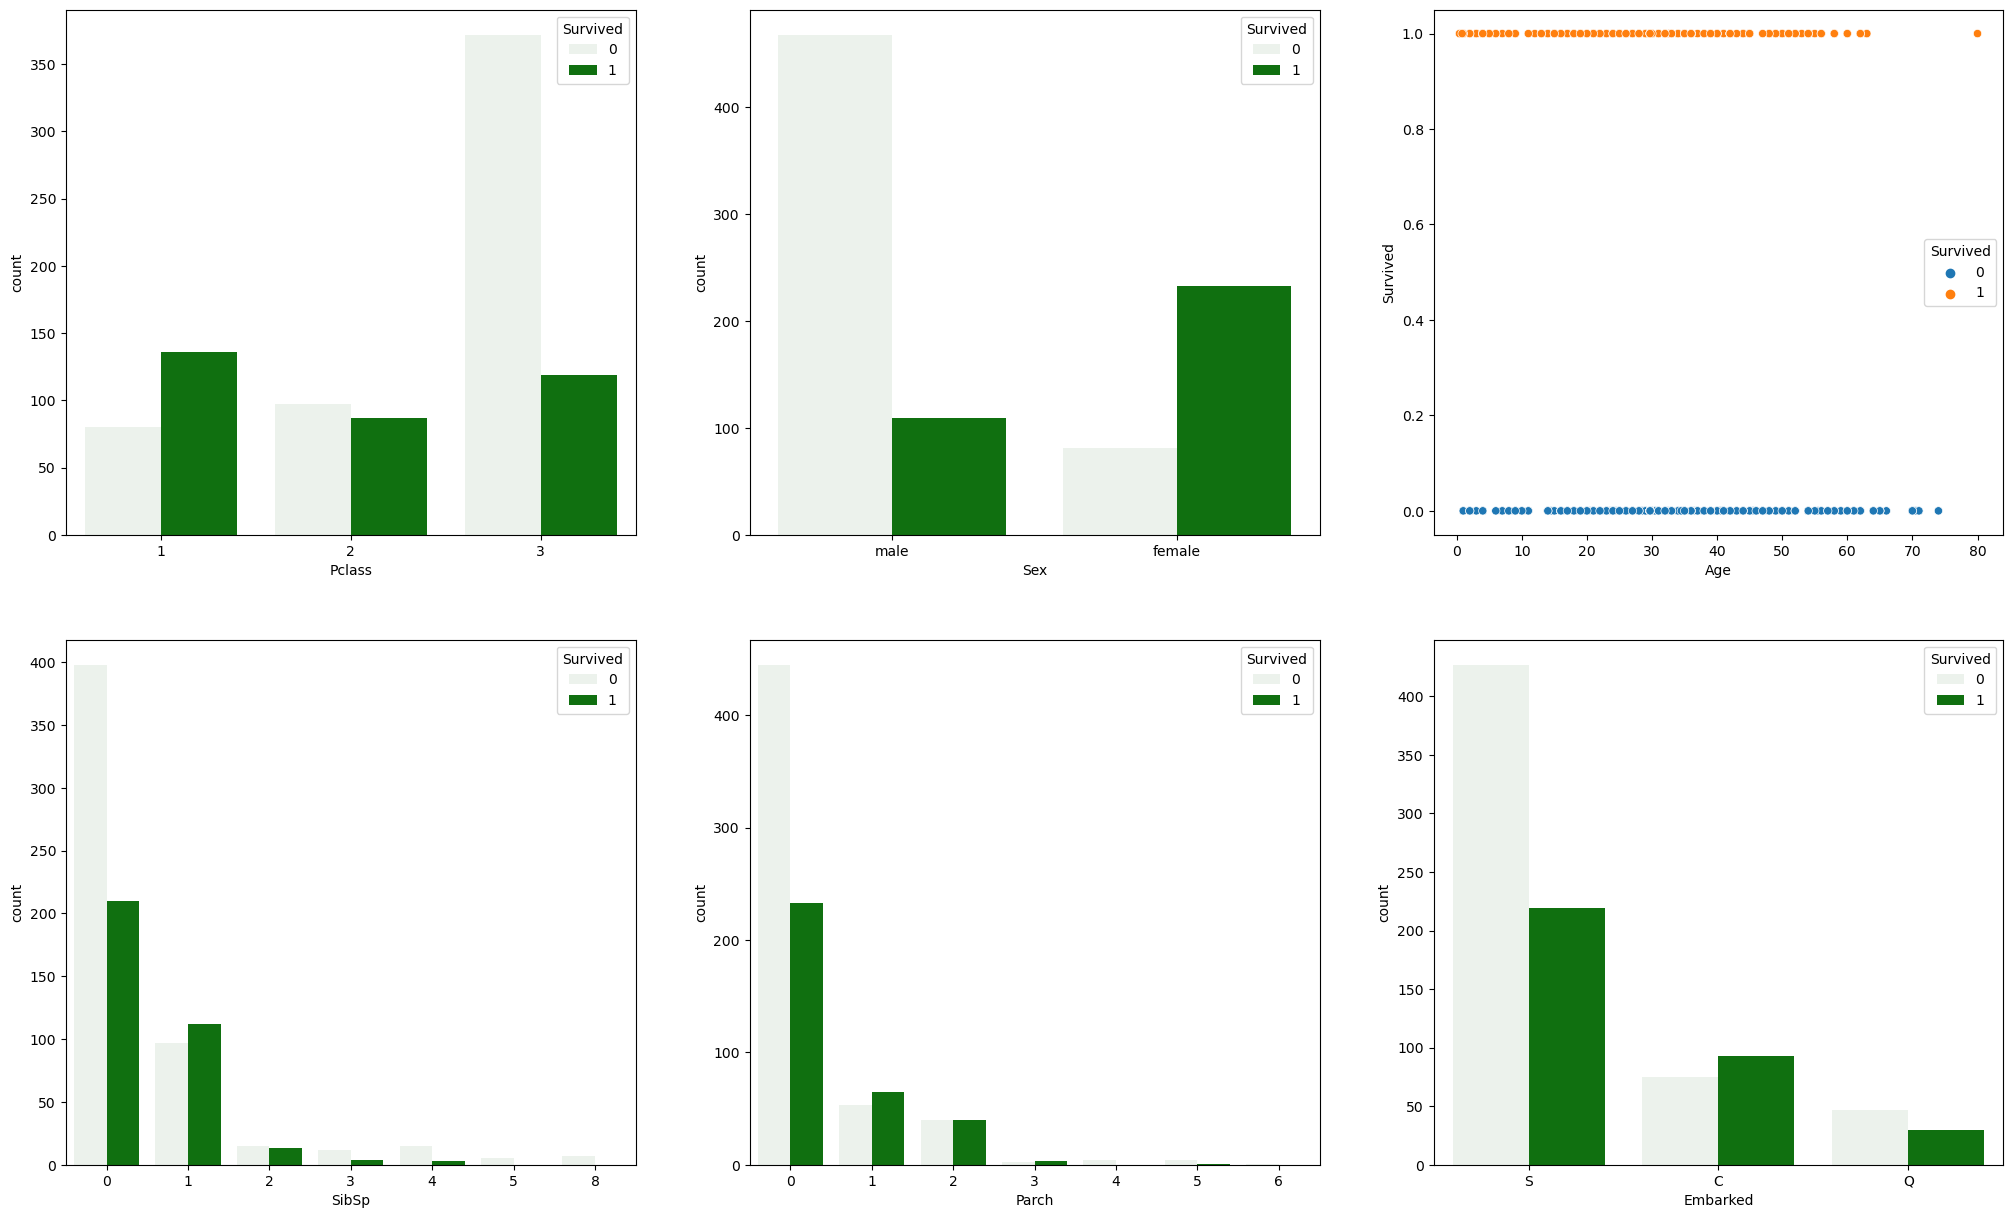

In [9]:
fig = plt.subplots(2,3, figsize =(25,15))
plt.subplot(2,3,1)
sns.countplot(x = df['Pclass'], data = df, hue = df['Survived'], color ='Green')
plt.subplot(2,3,2)
sns.countplot(x = df['Sex'],  data = df, hue = df['Survived'], color ='Green')
plt.subplot(2,3,3)
sns.scatterplot(x=df['Age'], y= df['Survived'], hue =df['Survived'], color ='Green')
plt.subplot(2,3,4)
sns.countplot(x = df['SibSp'],  data = df, hue = df['Survived'], color ='Green')
plt.subplot(2,3,5)
sns.countplot(x = df['Parch'],  data = df, hue = df['Survived'], color ='Green')
plt.subplot(2,3,6)
sns.countplot(x = df['Embarked'],  data = df, hue = df['Survived'], color ='Green')
plt.show()

##Dividing the Dataset into Features and Target Variable 

In [10]:
#Features
X = df[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Embarked']]

In [11]:
#Reviewing top 5 rows
X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Embarked
0,1,3,male,22.0,1,0,S
1,2,1,female,38.0,1,0,C
2,3,3,female,26.0,0,0,S
3,4,1,female,35.0,1,0,S
4,5,3,male,35.0,0,0,S


In [12]:
#Target Variable
Y = df[['Survived']]

In [13]:
#Reviewing top 5 rows
Y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


#Converting Categorical Columns into Numerical

We need to convert categorical columns into numerical ones so that they can be fitted by machine learning models which only take numerical data.

Using LabelEncoder for the encoding

In [14]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()

In [15]:
for i in X.columns:
  if X[i].dtypes =='object':
    X[i] = label_enc.fit_transform(X[i])

/tmp/ipykernel_20/1342277269.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i] = label_enc.fit_transform(X[i])
/tmp/ipykernel_20/1342277269.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i] = label_enc.fit_transform(X[i])


In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Embarked     891 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 48.9 KB


Here we can observe that datatype of all the columns are converted to either int or float

Spliting the Data into Training and Testing sets

In [17]:
#importing train_test_split from sklearn
from sklearn.model_selection import train_test_split

In [18]:
#Dividing dataset into training and testing 
X_train, x_test, Y_train, y_test = train_test_split(X,Y, test_size = 0.2, random_state =0)

## LogisticRegression

In [19]:
#Importing LogisticRegression from sklearn
from sklearn.linear_model import LogisticRegression

In [20]:
#Initialising LogisticRegression class into model object
model = LogisticRegression()

In [21]:
#feeding the training data to LogisticRegression model
model.fit(X_train, Y_train)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [22]:
#predicting the x_test values using the LogisticRegression model and saving the results in y_pred
y_pred = model.predict(x_test)

#Evaluation

In [23]:
#importing evaluation metrics such as confusion_matrix, accuracy_score from sklearn
from sklearn.metrics import confusion_matrix, accuracy_score

In [24]:
#calculating confusion_matrix
confusion_matrix(y_test, y_pred)

array([[95, 15],
       [21, 48]])

In [25]:
#calculating accuracy_score
accuracy_score(y_pred, y_test)*100

79.88826815642457

## DecisionTree

In [26]:
#importing DecisionTreeClassifier from sklearn
from sklearn.tree import DecisionTreeClassifier

In [27]:
#Initialising DecisionTreeClassifier class into clf object
clf = DecisionTreeClassifier()

In [28]:
#feeding the training data to DecisionTreeClassifier model
clf.fit(X_train, Y_train)

DecisionTreeClassifier()

In [29]:
#predicting the x_test values using the DecisionTreeClassifier model and saving the results in y_pred1
y_pred1 = clf.predict(x_test)

Evaluation

In [30]:
#calculating confusion_matrix
confusion_matrix(y_test, y_pred1)

array([[97, 13],
       [25, 44]])

In [31]:
#calculating accuracy_score
accuracy_score(y_pred1, y_test)*100

78.77094972067039

## RandomForest

In [32]:
#importing RandForestClassifier from sklearn
from sklearn.ensemble import RandomForestClassifier

In [33]:
#Initialising RandomForestClassifier class into rand_clf object
rand_clf = RandomForestClassifier(n_estimators = 200)

In [34]:
#feeding the training data to RandomForestClassifier model
rand_clf.fit(X_train, Y_train)

/tmp/ipykernel_20/1844496944.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rand_clf.fit(X_train, Y_train)


RandomForestClassifier(n_estimators=200)

In [35]:
#predicting the x_test values using the RandomForestClassifier model and saving the results in y_rand_pred
y_rand_pred = rand_clf.predict(x_test)

Evaluation

In [36]:
#calculating confusion_matrix
confusion_matrix(y_test, y_rand_pred)

array([[101,   9],
       [ 20,  49]])

In [37]:
#calculating accuracy_score
accuracy_score(y_rand_pred,y_test)*100

83.79888268156425

## XG BOOST

In [38]:
#importing XGBOOST as xgb
import xgboost as xgb

In [39]:
#Initialising XGBClassifier class into xgb_ object
xgb_ = xgb.XGBClassifier(n_estimators=5, max_depth =5)

In [40]:
#feeding the training data to XGBClassifier model
xgb_.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=5, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [41]:
#predicting the x_test values using the XGBClassifier model and saving the results in y_xgb_pred
y_xgb_pred = xgb_.predict(x_test)

Evaluation

In [42]:
#calculating confusion_matrix
confusion_matrix(y_test, y_xgb_pred)

array([[102,   8],
       [ 19,  50]])

In [43]:
#calculating accuracy_score
accuracy_score(y_xgb_pred, y_test)*100

84.91620111731844

## Reading the Testing Dataset using Pandas

In [44]:
df2 = pd.read_csv('/kaggle/input/titanic/test.csv')

Familiarizing with the data by reviewing the first 10 rows of the dataset and viewing the information about the data

In [45]:
df2.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [46]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


## Data Preprocessing

Checking for Null Values in the Training Dataset

In [47]:
df2.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

**Here we can observe that 'Age' and 'Cabin' Columns have Null values.

We need to handle the missing values in the dataset as missing values in data will lead to drawing inaccurate inference about the data.

In [48]:
#Imputing null values: Missing values can be imputed using the statistics i.e., using mean value for float or int datatype 
#and mode for object datatype.

for i in df2.columns:
  if df2[i].dtypes =='object':
    df2[i] = df2[i].fillna(df2[i].mode()[0])
  else:
    df2[i] = df2[i].fillna(df2[i].mean())

In [49]:
#Checking for null values after imputation
df2.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Checking for Duplicate values in Testing Dataset

In [50]:
df2.duplicated().sum()

0

We can observe that there are no duplicate values in the Testing Dataset

In [51]:
#Dropping the columns from the test dataset that were not used in the training dataset earlier.
df2.drop(['Name', 'Ticket','Fare','Cabin'], axis = 1, inplace =True)

In [52]:
df2.head(5)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Embarked
0,892,3,male,34.5,0,0,Q
1,893,3,female,47.0,1,0,S
2,894,2,male,62.0,0,0,Q
3,895,3,male,27.0,0,0,S
4,896,3,female,22.0,1,1,S


Converting Categorical Columns into Numerical using LabelEncoder

In [53]:
for i in df2.columns:
  if df2[i].dtypes == 'object':
    df2[i] = label_enc.fit_transform(df2[i])

In [54]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Embarked     418 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 23.0 KB


Here we can observe that datatype of all the columns are converted to either int or float

In [55]:
#predicting the df2 values using the LogisticRegression model and saving the results in y_test_model
y_test_model = model.predict(df2)

In [56]:
y_test_model 

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [57]:
#predicting the df2 values using the DecisionTreeClassifier model and saving the results in y_test_clf
y_test_clf = clf.predict(df2)

In [58]:
y_test_clf 

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,

In [59]:
#predicting the df2 values using the RandomForestClassifier model and saving the results in y_test_rand
y_test_rand = rand_clf.predict(df2)

In [60]:
y_test_rand

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [61]:
#predicting the df2 values using the XGBClassifier model and saving the results in y_test_xgb
y_test_xgb = xgb_.predict(df2)

In [62]:
y_test_xgb

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,